In [ ]:
# Data loading and Exploration 

In [2]:
import pandas as pd
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

In [7]:
df.dtypes

Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species              str
dtype: object

In [9]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [ ]:
# Task 2-Per-species Summary Statistics

In [34]:
mean_features= (df.groupby('Species').mean())
print(mean_features)

                    Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  \
Species                                                              
Iris-setosa       25.5          5.006         3.418          1.464   
Iris-versicolor   75.5          5.936         2.770          4.260   
Iris-virginica   125.5          6.588         2.974          5.552   

                 PetalWidthCm  
Species                        
Iris-setosa             0.244  
Iris-versicolor         1.326  
Iris-virginica          2.026  


In [10]:
print(df['Species'].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


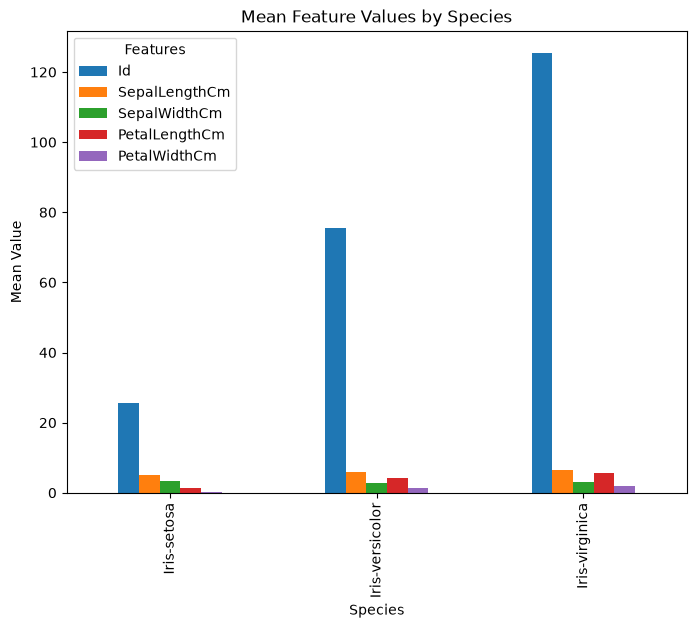

In [35]:
import matplotlib.pyplot as plt
mean_features.plot(kind='bar', figsize=(8, 6))
plt.title("Mean Feature Values by Species")
plt.xlabel("Species")
plt.ylabel("Mean Value")
plt.legend(title="Features")
plt.show()

In [ ]:
# Task 3-Distribution Analysis

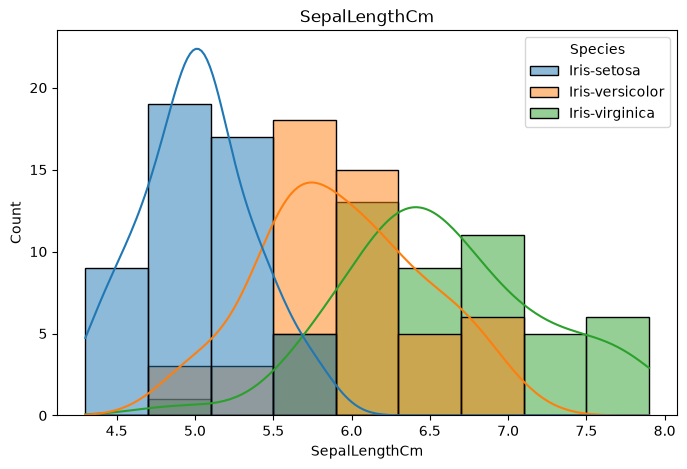

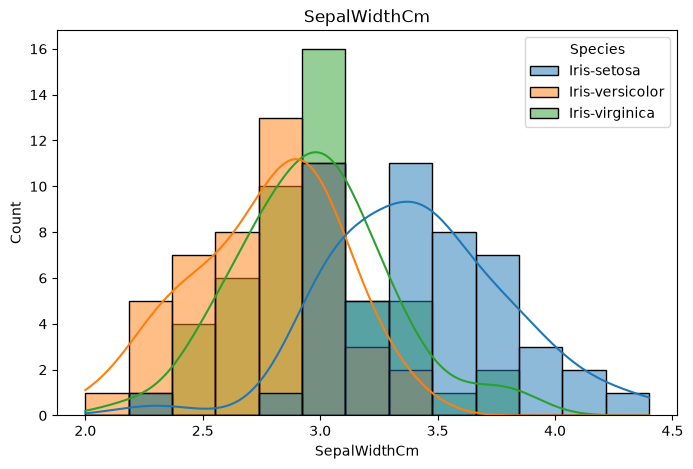

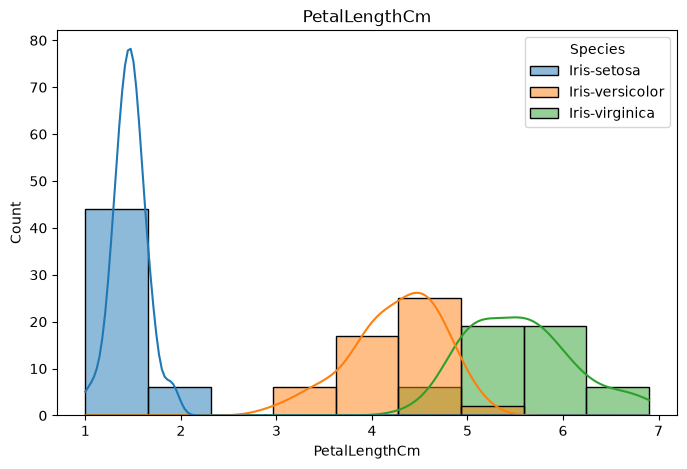

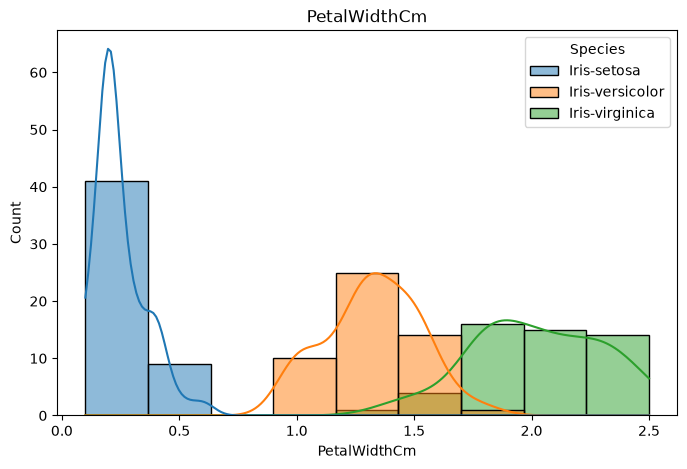

In [49]:
import seaborn as sns
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for feature in features:
    plt.figure(figsize=(8,5))
    sns.histplot(data=df, x=feature, hue='Species', kde=True)
    plt.title(feature)
    plt.show()

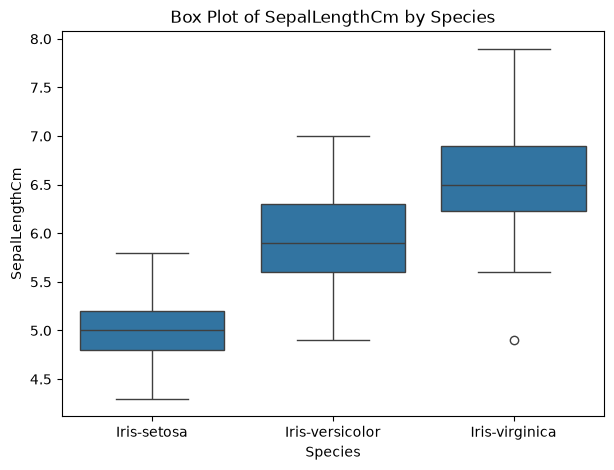

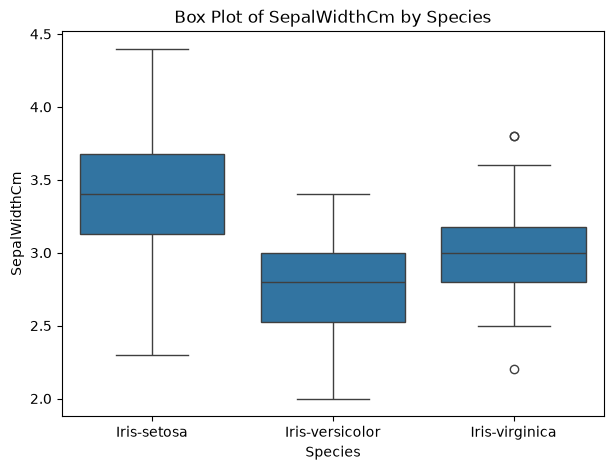

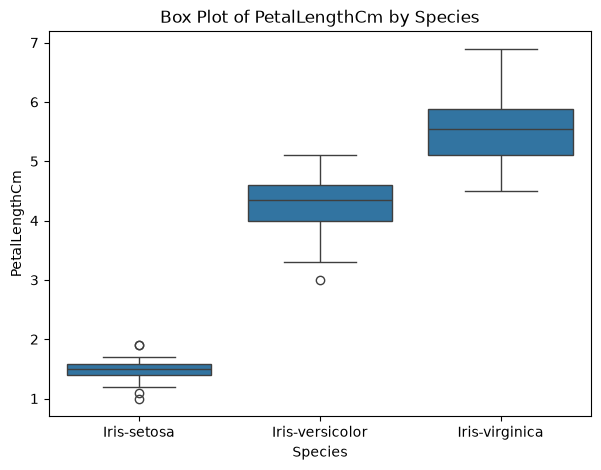

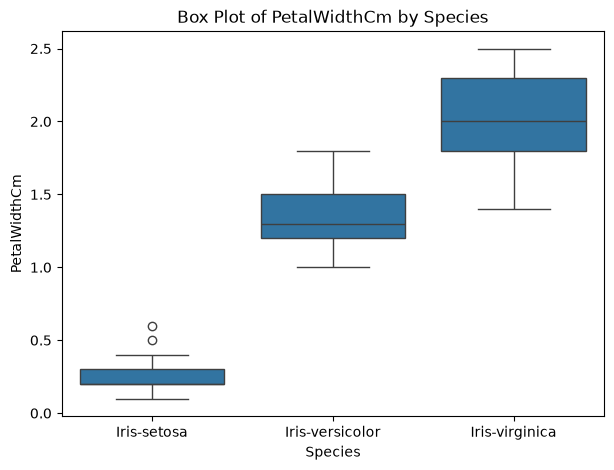

In [53]:
for feature in features:
    plt.figure(figsize=(7,5))
    sns.boxplot(data=df, x='Species', y=feature)
    plt.title(f"Box Plot of {feature} by Species")
    plt.xlabel("Species")
    plt.ylabel(feature)
    plt.show()

In [ ]:
# Comments: Petal Length and Petal Width are the best features for separating the three Iris species because their histograms and box plots show clear differences with minimal overlap. Sepal Length and Sepal Width have more overlap, making them less useful for distinguishing the species

In [54]:
import numpy as np
corr_matrix = df[features].corr()

print("Correlation Matrix:")
print(corr_matrix)

Correlation Matrix:
               SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
SepalLengthCm       1.000000     -0.109369       0.871754      0.817954
SepalWidthCm       -0.109369      1.000000      -0.420516     -0.356544
PetalLengthCm       0.871754     -0.420516       1.000000      0.962757
PetalWidthCm        0.817954     -0.356544       0.962757      1.000000


In [ ]:
#Task 4-Correlation Heatmap

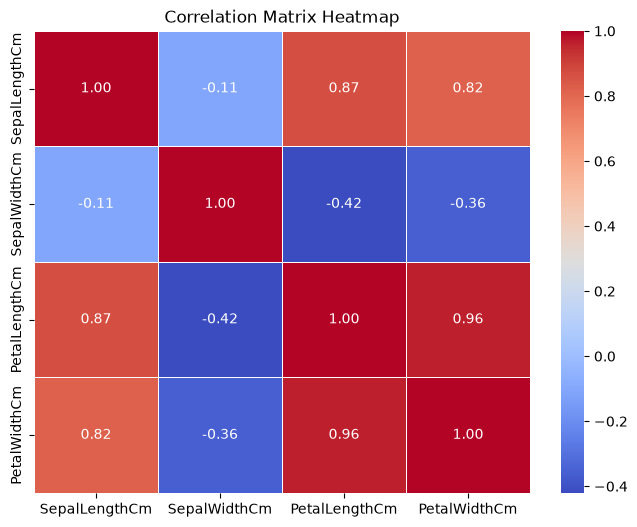

In [55]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
plt.show()

In [58]:
import numpy as np

corr = corr_matrix.abs().unstack()
corr = corr[corr < 1] 

print("Strongest Correlation:")
print(corr.idxmax())
print("Correlation Value:", corr.max())

Strongest Correlation:
('PetalLengthCm', 'PetalWidthCm')
Correlation Value: 0.9627570970509662
